### Importación de datos



In [187]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [188]:
# Cálculo de facturación
facturacion_t1 = tienda['Precio'].sum()
facturacion_t2 = tienda2['Precio'].sum()
facturacion_t3 = tienda3['Precio'].sum()
facturacion_t4 = tienda4['Precio'].sum()

# Almacenamiento y preparación de los datos
facturacion_total = {
    "Tienda 1": facturacion_t1,
    "Tienda 2": facturacion_t2,
    "Tienda 3": facturacion_t3,
    "Tienda 4": facturacion_t4
}

facturacion_df = pd.DataFrame.from_dict(facturacion_total, orient='index', columns=['Facturación Total'])
facturacion_df = facturacion_df.sort_values(by='Facturación Total', ascending=False).reset_index()
facturacion_df = facturacion_df.rename(columns={'index': 'Tienda'})

# Presentación numérica
print("Análisis de Facturación Total")

# Muestra los resultados
print(facturacion_df.to_string(index=False, float_format='${:,.2f}'.format))

# Determina la tienda con menor facturación
tienda_menor_facturacion = facturacion_df['Tienda'].iloc[-1]
monto_menor_facturacion = facturacion_df['Facturación Total'].iloc[-1]

print("\nConclusión de Facturación:")
print(f"La tienda con la menor facturación es: {tienda_menor_facturacion} con un total de ${monto_menor_facturacion:,.2f}.")


Análisis de Facturación Total
  Tienda  Facturación Total
Tienda 1  $1,150,880,400.00
Tienda 2  $1,116,343,500.00
Tienda 3  $1,098,019,600.00
Tienda 4  $1,038,375,700.00

Conclusión de Facturación:
La tienda con la menor facturación es: Tienda 4 con un total de $1,038,375,700.00.


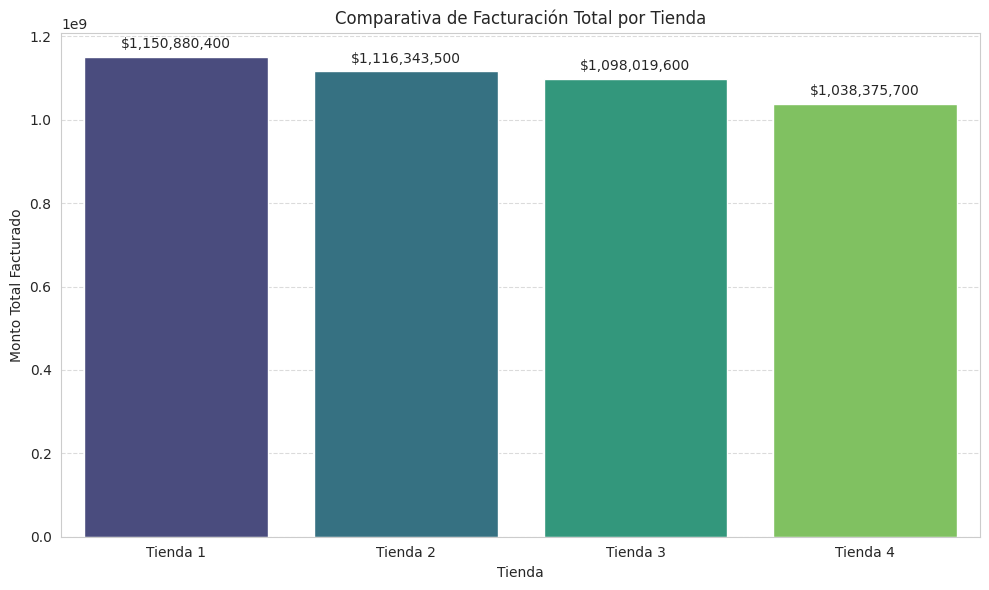

In [189]:
# Generación de la gráfica con la librería Seaborn
plt.figure(figsize=(10, 6))

# Gráfico de barras (barplot) usa la variable 'facturacion_df'
ax = sns.barplot(x='Tienda', y='Facturación Total', data=facturacion_df, hue='Tienda', palette='viridis', legend=False)

plt.title('Comparativa de Facturación Total por Tienda')
plt.ylabel('Monto Total Facturado')
plt.xlabel('Tienda')

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [190]:
# Función para calcular el Top 5 de categorías para una tienda
def obtener_top_categorias(df):
    # Usa value_counts() para contar y to_dict() para almacenar el resumen
    return df['Categoría del Producto'].value_counts().head(5).to_dict()

# Calcular y almacenar el Top 5 para cada tienda
analisis_categorias = {
    "Tienda 1": obtener_top_categorias(tienda),
    "Tienda 2": obtener_top_categorias(tienda2),
    "Tienda 3": obtener_top_categorias(tienda3),
    "Tienda 4": obtener_top_categorias(tienda4)
}

# Función auxiliar para convertir el diccionario a un DataFrame por tienda
def dict_a_df(data_dict, tienda_nombre):
    df = pd.DataFrame(list(data_dict.items()), columns=['Categoría', 'Conteo'])
    df['Tienda'] = tienda_nombre
    return df

# Creación del DataFrame CONSOLIDADO
analisis_categorias_df = pd.concat([
    dict_a_df(analisis_categorias["Tienda 1"], "Tienda 1"),
    dict_a_df(analisis_categorias["Tienda 2"], "Tienda 2"),
    dict_a_df(analisis_categorias["Tienda 3"], "Tienda 3"),
    dict_a_df(analisis_categorias["Tienda 4"], "Tienda 4")
])

# Presentación numérica
print("Ventas por Categoría: Categorías Más Populares 'Top 5'")

for nombre_tienda, categorias in analisis_categorias.items():
    print(f"\n**{nombre_tienda}**")

    # Imprimir las categorías y su conteo
    for categoria, conteo in categorias.items():
        print(f"  - {categoria}: {conteo} ventas")

Ventas por Categoría: Categorías Más Populares 'Top 5'

**Tienda 1**
  - Muebles: 465 ventas
  - Electrónicos: 448 ventas
  - Juguetes: 324 ventas
  - Electrodomésticos: 312 ventas
  - Deportes y diversión: 284 ventas

**Tienda 2**
  - Muebles: 442 ventas
  - Electrónicos: 422 ventas
  - Juguetes: 313 ventas
  - Electrodomésticos: 305 ventas
  - Deportes y diversión: 275 ventas

**Tienda 3**
  - Muebles: 499 ventas
  - Electrónicos: 451 ventas
  - Juguetes: 315 ventas
  - Electrodomésticos: 278 ventas
  - Deportes y diversión: 277 ventas

**Tienda 4**
  - Muebles: 480 ventas
  - Electrónicos: 451 ventas
  - Juguetes: 338 ventas
  - Deportes y diversión: 277 ventas
  - Electrodomésticos: 254 ventas


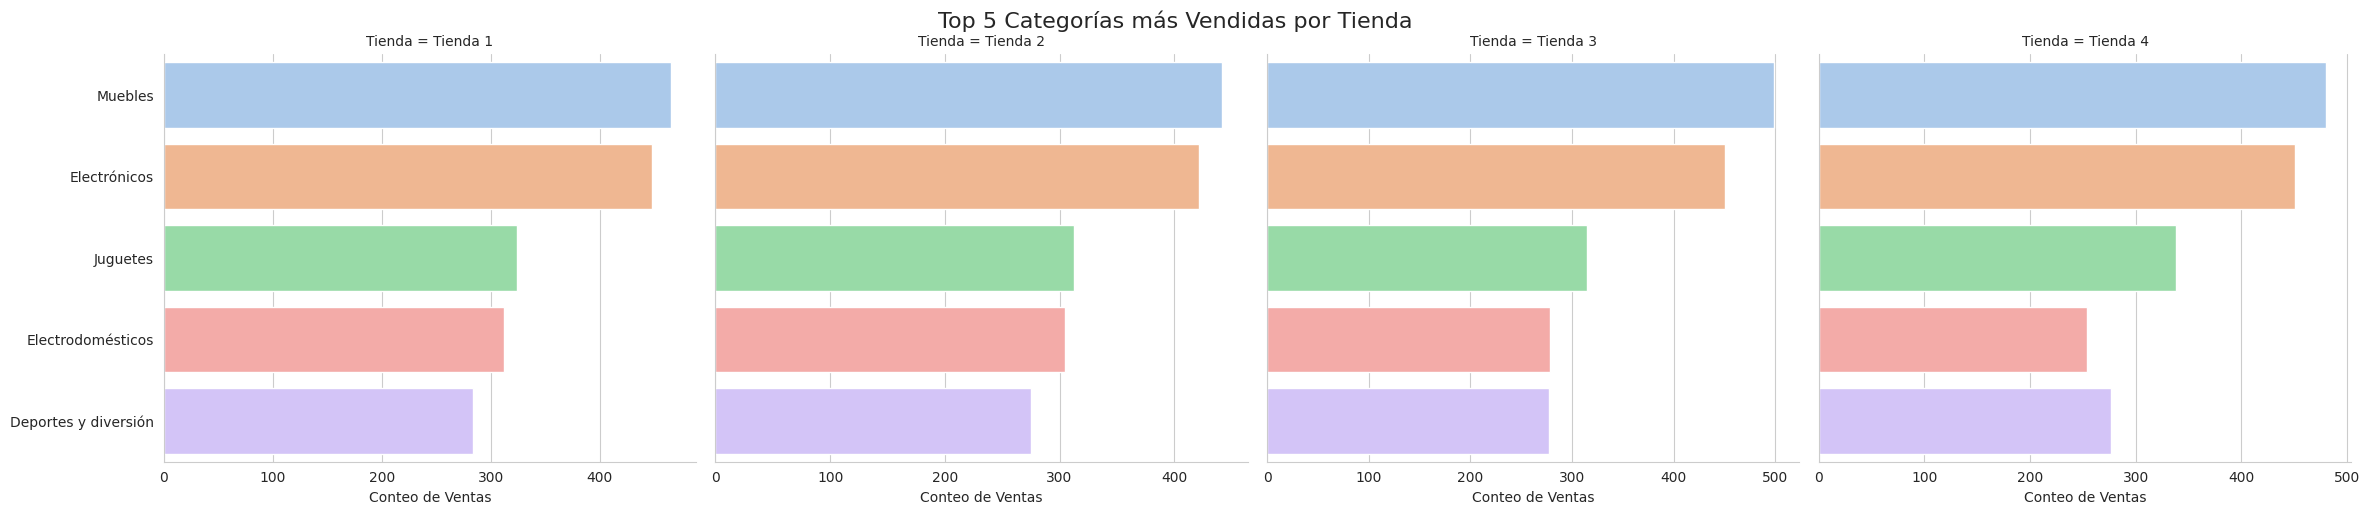

In [191]:
# Generación de la gráfica con la librería Seaborn
sns.set_style("whitegrid")

# Usamos sns.catplot para crear un gráfico de barras separado para cada tienda (FacetGrid)
g = sns.catplot(
    data=analisis_categorias_df,
    x="Conteo",
    y="Categoría",
    col="Tienda",  # Esto separa los gráficos por tienda
    kind="bar",
    sharex=False, # Importante: Permite que cada gráfico tenga su propio eje X (Conteo)
    palette="pastel",
    height=5,
    aspect=1.2,
    hue="Categoría",
    legend=False
)

g.fig.suptitle('Top 5 Categorías más Vendidas por Tienda', y=1.02, fontsize=16)
g.set_axis_labels("Conteo de Ventas", "")
plt.show()

# 3. Calificación promedio de la tienda


In [192]:
# Calcular la calificación promedio (media) de los clientes para cada tienda
calificacion_t1 = tienda['Calificación'].mean()
calificacion_t2 = tienda2['Calificación'].mean()
calificacion_t3 = tienda3['Calificación'].mean()
calificacion_t4 = tienda4['Calificación'].mean()

# Almacenar los resultados en un diccionario
calificacion_promedio = {
    "Tienda 1": calificacion_t1,
    "Tienda 2": calificacion_t2,
    "Tienda 3": calificacion_t3,
    "Tienda 4": calificacion_t4
}

# Creación del DataFrame CONSOLIDADO
calif_df = pd.DataFrame.from_dict(calificacion_promedio, orient='index', columns=['Calificación Promedio'])
calif_df = calif_df.sort_values(by='Calificación Promedio', ascending=False).reset_index()
calif_df = calif_df.rename(columns={'index': 'Tienda'})
# -----------------------------------------------------

# Presentación numérica
print("Calificación Promedio de la Tienda")
print(calif_df.to_string(index=False, float_format='{:.2f}'.format))

# Determinar la tienda con la calificación más baja
tienda_menor_calif = calif_df['Tienda'].iloc[-1]
calif_menor = calif_df['Calificación Promedio'].iloc[-1]

print("\nConclusión de Calificación:")
print(f"La tienda con la **menor calificación promedio** es: **{tienda_menor_calif}** ({calif_menor:.2f}).")

Calificación Promedio de la Tienda
  Tienda  Calificación Promedio
Tienda 3                   4.05
Tienda 2                   4.04
Tienda 4                   4.00
Tienda 1                   3.98

Conclusión de Calificación:
La tienda con la **menor calificación promedio** es: **Tienda 1** (3.98).


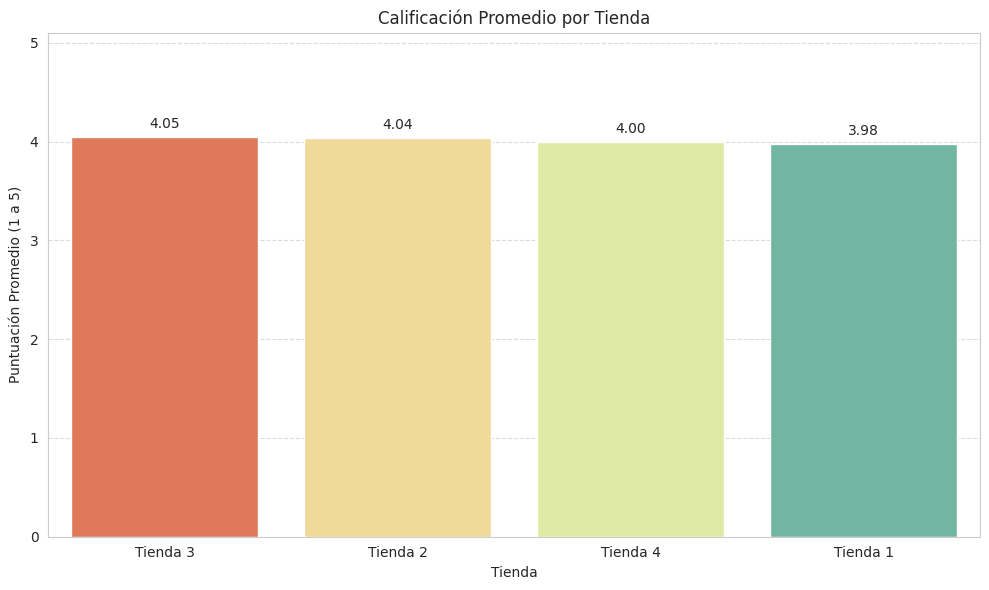

In [193]:
# Generación de la gráfica con la librería Seaborn
plt.figure(figsize=(10, 6))

# Gráfico de barras (barplot) es ideal para comparar los promedios
ax = sns.barplot(x='Tienda', y='Calificación Promedio', data=calif_df, hue='Tienda', palette='Spectral', legend=False)

plt.title('Calificación Promedio por Tienda')
plt.ylabel('Puntuación Promedio (1 a 5)')
plt.xlabel('Tienda')
plt.ylim(0, 5.1) # Establecer límite Y de 0 a 5 para un contexto claro

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [194]:
# Función para encontrar y almacenar el producto más y menos vendido
def obtener_extremos_productos(df):
    # Conteo de ocurrencias de cada producto, ordenado
    conteo_productos = df['Producto'].value_counts()

    # Devolver el diccionario con los extremos
    return {
        "Mas Vendido": conteo_productos.index[0],
        "Cantidad Mas Vendido": int(conteo_productos.iloc[0]),
        "Menos Vendido": conteo_productos.index[-1],
        "Cantidad Menos Vendido": int(conteo_productos.iloc[-1])
    }

# Calcular y almacenar los extremos para cada tienda
extremos_productos = {
    "Tienda 1": obtener_extremos_productos(tienda),
    "Tienda 2": obtener_extremos_productos(tienda2),
    "Tienda 3": obtener_extremos_productos(tienda3),
    "Tienda 4": obtener_extremos_productos(tienda4)
}

# Presentación numérica
print("Productos Más y Menos Vendidos (por cantidad de transacciones)")

for nombre_tienda, extremos in extremos_productos.items():
    print(f"\n{nombre_tienda}")
    print(f"Más Vendido: {extremos['Mas Vendido']} (Ventas: {extremos['Cantidad Mas Vendido']})")
    print(f"Menos Vendido: {extremos['Menos Vendido']} (Ventas: {extremos['Cantidad Menos Vendido']})")

print("\nConclusión: La existencia de productos con pocas ventas (ej. 1) puede indicar bajo rendimiento o artículos nicho/nuevos.")

Productos Más y Menos Vendidos (por cantidad de transacciones)

Tienda 1
Más Vendido: Microondas (Ventas: 60)
Menos Vendido: Celular ABXY (Ventas: 33)

Tienda 2
Más Vendido: Iniciando en programación (Ventas: 65)
Menos Vendido: Juego de mesa (Ventas: 32)

Tienda 3
Más Vendido: Kit de bancas (Ventas: 57)
Menos Vendido: Bloques de construcción (Ventas: 35)

Tienda 4
Más Vendido: Cama box (Ventas: 62)
Menos Vendido: Guitarra eléctrica (Ventas: 33)

Conclusión: La existencia de productos con pocas ventas (ej. 1) puede indicar bajo rendimiento o artículos nicho/nuevos.


# 5. Envío promedio por tienda

In [195]:
# Calcular el costo de envío promedio para cada tienda
envio_promedio_t1 = tienda['Costo de envío'].mean()
envio_promedio_t2 = tienda2['Costo de envío'].mean()
envio_promedio_t3 = tienda3['Costo de envío'].mean()
envio_promedio_t4 = tienda4['Costo de envío'].mean()

# Almacenar los resultados en un diccionario
envio_promedio = {
    "Tienda 1": envio_promedio_t1,
    "Tienda 2": envio_promedio_t2,
    "Tienda 3": envio_promedio_t3,
    "Tienda 4": envio_promedio_t4
}

# Creación del DataFrame CONSOLIDADO
envio_df = pd.DataFrame.from_dict(envio_promedio, orient='index', columns=['Costo Promedio de Envío'])
envio_df = envio_df.sort_values(by='Costo Promedio de Envío', ascending=False).reset_index()
envio_df = envio_df.rename(columns={'index': 'Tienda'})
# -----------------------------------------------------

# Presentación numérica
print("Costo de Envío Promedio por Tienda")
print(envio_df.to_string(index=False, float_format='${:,.2f}'.format))

# Determinar la tienda con el costo de envío más alto
tienda_mayor_envio = envio_df['Tienda'].iloc[0]
costo_mayor = envio_df['Costo Promedio de Envío'].iloc[0]

print("\nConclusión de Envío:")
print(f"La tienda con el mayor costo de envío promedio es: {tienda_mayor_envio} (${costo_mayor:,.2f}).")

Costo de Envío Promedio por Tienda
  Tienda  Costo Promedio de Envío
Tienda 1               $26,018.61
Tienda 2               $25,216.24
Tienda 3               $24,805.68
Tienda 4               $23,459.46

Conclusión de Envío:
La tienda con el mayor costo de envío promedio es: Tienda 1 ($26,018.61).


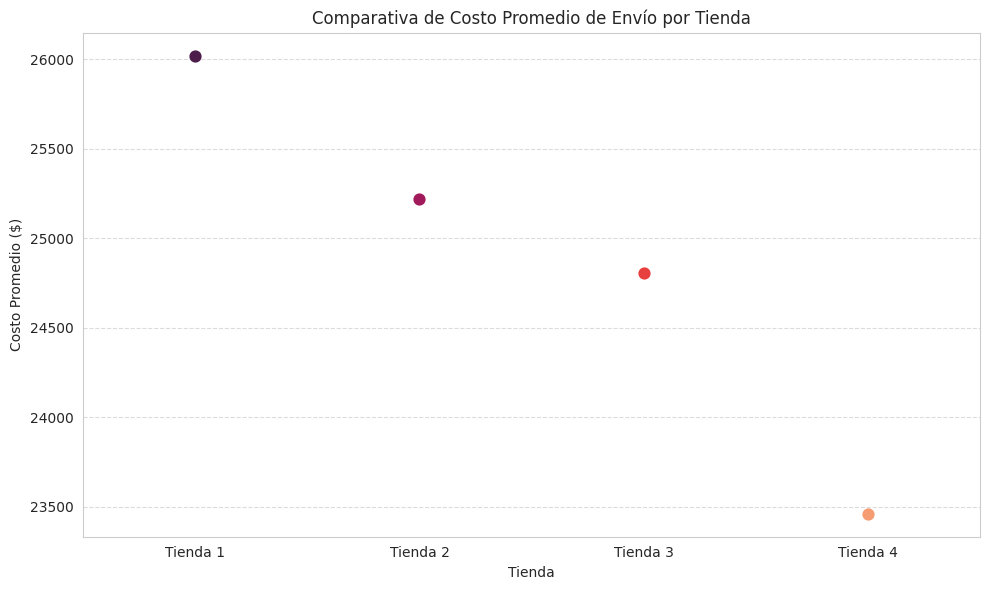

In [196]:
# Generación de la gráfica con la librería Seaborn
plt.figure(figsize=(10, 6))

# Gráfico de barras (pointplot) es ideal para comparar los promedios
ax = sns.pointplot(x='Tienda', y='Costo Promedio de Envío', data=envio_df, hue='Tienda', palette='rocket', legend=False)

plt.title('Comparativa de Costo Promedio de Envío por Tienda')
plt.ylabel('Costo Promedio ($)')
plt.xlabel('Tienda')

# Desactivar el formato científico (eliminar 1eX)
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False, useMathText=False))
ax.ticklabel_format(style='plain', axis='y')

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()